In [1]:
import os
import torch
import numpy as np
from ultralytics import YOLO
from glob import glob
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
from tqdm import tqdm
import time
import psutil
import gc
import cv2


In [2]:
# === SETUP ===
test_img_dir = (
    r"E:\Thesis - Coffee\Local Training\Data\Coffee-Leaf-Diseases---OD-10\test\images"
)
label_path_root = (
    r"E:\Thesis - Coffee\Local Training\Data\Coffee-Leaf-Diseases---OD-10\test\labels"
)
image_paths = sorted(glob(os.path.join(test_img_dir, "*.jpg")))

class_names = ["abiotic disorder", "cercospora", "healthy", "rust", "sooty mold"]


In [3]:
# === Memory Management Functions ===
def show_memory_usage():
    """Display current memory usage"""
    process = psutil.Process(os.getpid())
    memory_info = process.memory_info()
    print(f"Memory usage: {memory_info.rss / (1024 * 1024):.2f} MB")

    if torch.cuda.is_available():
        print(
            f"CUDA memory allocated: {torch.cuda.memory_allocated() / (1024 * 1024):.2f} MB"
        )
        print(
            f"CUDA memory reserved: {torch.cuda.memory_reserved() / (1024 * 1024):.2f} MB"
        )


def cleanup_memory():
    """Force garbage collection and clear CUDA cache if available"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()  # Ensure all CUDA operations are completed


In [4]:
model_paths = [
    "paths/Yolo8n.pt",
    "paths/Yolo11n.pt",
    "paths/Yolo12n.pt",
    "paths/Yolo8m.pt",
    "paths/Yolo11m.pt",
    "paths/Yolo12m.pt",
]


In [5]:
def get_model_name(model_path):
    """Extract a clean model name from the model path"""
    # Get the filename without directory
    filename = os.path.basename(model_path)
    # Remove file extension
    model_name = os.path.splitext(filename)[0]
    return model_name


In [6]:
print(f"Found {len(image_paths)} test images")


Found 105 test images


In [7]:
# Load models
def load_models(model_paths):
    models = []
    for path in model_paths:
        try:
            model = YOLO(path)
            models.append(model)
            print(f"Successfully loaded model: {path}")
        except Exception as e:
            print(f"Error loading model {path}: {e}")
    return models


# Debug function to print box information
def debug_boxes(gt_boxes, gt_labels, pred_boxes, pred_labels, image_name):
    print(f"\nDEBUG INFO FOR: {image_name}")
    print(f"Ground Truth: {len(gt_boxes)} boxes")
    for i, (box, label) in enumerate(zip(gt_boxes, gt_labels)):
        print(
            f"  GT Box {i}: {box}, Class: {label} ({class_names[int(label)] if int(label) < len(class_names) else 'unknown'})"
        )

    print(f"Predictions: {len(pred_boxes)} boxes")
    for i, (box, label) in enumerate(zip(pred_boxes, pred_labels)):
        print(
            f"  Pred Box {i}: {box}, Class: {label} ({class_names[int(label)] if int(label) < len(class_names) else 'unknown'})"
        )


In [8]:
# Load ground truth labels with proper format conversion
def load_ground_truth(image_path, label_path_root):
    """Load ground truth labels for an image with proper format conversion"""
    image_name = os.path.basename(image_path)
    label_name = os.path.splitext(image_name)[0] + ".txt"
    label_path = os.path.join(label_path_root, label_name)

    boxes = []
    labels = []

    # Get image dimensions for conversion
    import cv2

    img = cv2.imread(image_path)
    if img is None:
        print(f"Warning: Could not read image {image_path}")
        return np.array([]), np.array([])

    img_height, img_width = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    label = int(parts[0])
                    # YOLO format: class x_center y_center width height (normalized)
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])

                    # Convert normalized coordinates to absolute
                    x_center_abs = x_center * img_width
                    y_center_abs = y_center * img_height
                    width_abs = width * img_width
                    height_abs = height * img_height

                    # Convert to [x1, y1, x2, y2] format
                    x1 = x_center_abs - width_abs / 2
                    y1 = y_center_abs - height_abs / 2
                    x2 = x_center_abs + width_abs / 2
                    y2 = y_center_abs + height_abs / 2

                    boxes.append([x1, y1, x2, y2])
                    labels.append(label)
    else:
        print(f"Warning: Label file not found: {label_path}")

    return np.array(boxes) if boxes else np.array([]), np.array(
        labels
    ) if labels else np.array([])


# Calculate IoU between boxes
def calculate_iou(box1, box2):
    """Calculate IoU between two boxes in [x1, y1, x2, y2] format"""
    # Box coordinates
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2

    # Calculate intersection area
    x1_i = max(x1_1, x1_2)
    y1_i = max(y1_1, y1_2)
    x2_i = min(x2_1, x2_2)
    y2_i = min(y2_1, y2_2)

    if x2_i < x1_i or y2_i < y1_i:
        return 0.0

    intersection_area = (x2_i - x1_i) * (y2_i - y1_i)

    # Calculate union area
    box1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
    box2_area = (x2_2 - x1_2) * (y2_2 - y1_2)
    union_area = box1_area + box2_area - intersection_area

    return intersection_area / union_area if union_area > 0 else 0.0

In [47]:
def filtering_ensemble_predict(models, image_path, weights=None, conf_threshold=0.25, timeout=60):
    """
    Filtering ensemble approach that selectively combines predictions from multiple models
    based on confidence and agreement between models.
    """
    start_time = time.time()

    if weights is None:
        weights = [1 / len(models)] * len(models)

    # Run inference with each model
    model_predictions = []
    
    try:
        for i, model in enumerate(models):
            # Check for timeout
            if time.time() - start_time > timeout:
                print(f"Warning: Timeout exceeded for {image_path}, returning partial results")
                break

            # Use with torch.no_grad() to reduce memory usage
            with torch.no_grad():
                results = model(image_path)
                result = results[0]

                # Skip if no detections
                if result.boxes is None or len(result.boxes) == 0:
                    model_predictions.append([])
                    continue

                # Get boxes, scores, and classes with proper detachment
                boxes = result.boxes.xyxy.detach().cpu().numpy()
                confs = result.boxes.conf.detach().cpu().numpy()
                cls_ids = result.boxes.cls.detach().cpu().numpy()

                # Apply confidence threshold
                mask = confs >= conf_threshold
                if np.any(mask):
                    filtered_boxes = boxes[mask]
                    filtered_confs = confs[mask]
                    filtered_cls_ids = cls_ids[mask]
                    
                    # Store predictions for this model
                    preds = []
                    for j in range(len(filtered_boxes)):
                        preds.append({
                            "box": filtered_boxes[j],
                            "score": filtered_confs[j], 
                            "class": filtered_cls_ids[j]
                        })
                    model_predictions.append(preds)
                else:
                    model_predictions.append([])

                # Force cleanup after each model inference
                del results, result
                gc.collect()

        # If no detections from any model
        if all(len(preds) == 0 for preds in model_predictions):
            return np.array([]), np.array([]), np.array([])

        # STEP 1: Find predictions that appear in multiple models (consensus filtering)
        consensus_predictions = []
        
        # For each model's predictions
        for i, model_preds in enumerate(model_predictions):
            for pred in model_preds:
                # Check if this prediction has support from other models
                has_support = False
                supporting_models = 1  # Count current model
                
                # Compare with predictions from other models
                for j, other_model_preds in enumerate(model_predictions):
                    if i == j:  # Skip same model
                        continue
                        
                    for other_pred in other_model_preds:
                        # Check if same class and high IoU
                        if (pred["class"] == other_pred["class"] and 
                            calculate_iou(pred["box"], other_pred["box"]) > 0.5):
                            has_support = True
                            supporting_models += 1
                            break
                
                # Calculate confidence boost based on supporting models
                confidence_boost = min(1.0, pred["score"] * (1.0 + 0.1 * (supporting_models - 1)))
                
                # Add to consensus predictions with boosted confidence
                consensus_predictions.append({
                    "box": pred["box"],
                    "score": confidence_boost,
                    "class": pred["class"],
                    "support": supporting_models
                })
        
        # STEP 2: Apply class-specific filtering
        # Different classes might need different confidence thresholds
        class_conf_thresholds = {}
        for cls in range(len(class_names)):
            
            # Lower all thresholds
            class_conf_thresholds[cls] = conf_threshold * 0.8  # Reduce by 20%
            
            # # Default threshold
            # class_conf_thresholds[cls] = conf_threshold
            
            # # For classes that tend to have more false positives, use higher threshold
            # if cls in [0, 2]:  # Adjust based on your class indices
            #     class_conf_thresholds[cls] = conf_threshold * 1.2
                
            # # For classes that are harder to detect, use lower threshold
            # if cls in [3, 4]:  # Adjust based on your class indices
            #     class_conf_thresholds[cls] = conf_threshold * 0.9
        
        # Filter predictions based on class-specific thresholds and support
        filtered_predictions = []
        for pred in consensus_predictions:
            cls = int(pred["class"])
            # Apply stricter filtering for predictions with low support
            if pred["support"] == 1:  # Only one model detected this
                if pred["score"] > class_conf_thresholds[cls] * 1.1:  # Higher threshold for single-model predictions
                    filtered_predictions.append(pred)
            else:  # Multiple models detected this
                if pred["score"] > class_conf_thresholds[cls]:
                    filtered_predictions.append(pred)
        
        # STEP 3: Apply NMS to remove duplicates
        # Group by class
        class_predictions = {}
        for pred in filtered_predictions:
            cls = int(pred["class"])
            if cls not in class_predictions:
                class_predictions[cls] = []
            class_predictions[cls].append(pred)
        
        # Apply NMS for each class
        final_boxes = []
        final_scores = []
        final_classes = []
        
        for cls, preds in class_predictions.items():
            # Sort by score
            preds.sort(key=lambda x: x["score"], reverse=True)
            
            # Apply NMS
            keep_indices = []
            for i in range(len(preds)):
                keep = True
                for j in keep_indices:
                    if calculate_iou(preds[i]["box"], preds[j]["box"]) > 0.5:
                        keep = False
                        break
                if keep:
                    keep_indices.append(i)
            
            # Add kept predictions to final results
            for i in keep_indices:
                final_boxes.append(preds[i]["box"])
                final_scores.append(preds[i]["score"])
                final_classes.append(preds[i]["class"])
        
        # If no final predictions
        if len(final_boxes) == 0:
            return np.array([]), np.array([]), np.array([])
            
        return np.array(final_boxes), np.array(final_scores), np.array(final_classes)
        
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return np.array([]), np.array([]), np.array([])
    finally:
        # Always clean up memory
        gc.collect()
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

In [10]:
# Evaluate model with detailed debugging
def evaluate_model_fixed(
    model,
    image_paths,
    label_path_root,
    max_images=None,
    iou_threshold=0.5,
    conf_threshold=0.25,
):
    """Evaluate a single model's performance with detailed debugging"""
    # Limit number of images if specified
    if max_images is not None:
        image_paths = image_paths[:max_images]

    # Initialize metrics
    total_gt = 0
    total_pred = 0
    total_correct = 0

    # Lists to store class predictions and ground truth for metrics
    all_pred_classes = []
    all_gt_classes = []

    # Lists to store precision and recall for each class
    class_metrics = {}

    # Initialize per-class counters
    class_counts = {}
    for i, name in enumerate(class_names):
        class_counts[i] = {"gt": 0, "pred": 0, "correct": 0}

    print(f"Evaluating model on {len(image_paths)} images...")

    for img_idx, image_path in enumerate(image_paths):
        image_name = os.path.basename(image_path)

        # Get ground truth
        gt_boxes, gt_labels = load_ground_truth(image_path, label_path_root)

        # Update ground truth counts
        for label in gt_labels:
            if int(label) in class_counts:
                class_counts[int(label)]["gt"] += 1

        # Get predictions
        results = model(image_path)
        result = results[0]

        pred_boxes = []
        pred_scores = []
        pred_labels = []

        if result.boxes is not None and len(result.boxes) > 0:
            for i in range(len(result.boxes)):
                conf = result.boxes.conf[i].item()
                if conf >= conf_threshold:
                    box = result.boxes.xyxy[i].cpu().numpy()
                    cls = int(result.boxes.cls[i].item())

                    pred_boxes.append(box)
                    pred_scores.append(conf)
                    pred_labels.append(cls)

                    # Update prediction counts
                    if cls in class_counts:
                        class_counts[cls]["pred"] += 1

        # Convert to numpy arrays
        pred_boxes = np.array(pred_boxes) if pred_boxes else np.array([])
        pred_labels = np.array(pred_labels) if pred_labels else np.array([])

        # Update counts
        total_gt += len(gt_boxes)
        total_pred += len(pred_boxes)

        # Debug output for first few images
        if img_idx < 3:  # Show debug info for first 3 images
            debug_boxes(gt_boxes, gt_labels, pred_boxes, pred_labels, image_name)

        # Match predictions to ground truth
        gt_matched = np.zeros(len(gt_boxes), dtype=bool)

        for i, pred_box in enumerate(pred_boxes):
            best_iou = 0
            best_gt_idx = -1

            # Find best matching ground truth box
            for j, gt_box in enumerate(gt_boxes):
                if not gt_matched[j]:
                    iou = calculate_iou(pred_box, gt_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = j

            # If match found with sufficient IoU
            if best_gt_idx >= 0 and best_iou >= iou_threshold:
                gt_matched[best_gt_idx] = True

                # Check if class prediction is correct
                if pred_labels[i] == gt_labels[best_gt_idx]:
                    total_correct += 1

                    # Update correct counts
                    if pred_labels[i] in class_counts:
                        class_counts[pred_labels[i]]["correct"] += 1

                # Store class predictions and ground truth for metrics
                all_pred_classes.append(pred_labels[i])
                all_gt_classes.append(gt_labels[best_gt_idx])

    # Calculate metrics
    precision = total_correct / total_pred if total_pred > 0 else 0
    recall = total_correct / total_gt if total_gt > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    )

    # Calculate per-class metrics
    for cls in class_counts:
        gt_count = class_counts[cls]["gt"]
        pred_count = class_counts[cls]["pred"]
        correct_count = class_counts[cls]["correct"]

        cls_precision = correct_count / pred_count if pred_count > 0 else 0
        cls_recall = correct_count / gt_count if gt_count > 0 else 0
        cls_f1 = (
            2 * cls_precision * cls_recall / (cls_precision + cls_recall)
            if (cls_precision + cls_recall) > 0
            else 0
        )

        class_metrics[cls] = {
            "precision": cls_precision,
            "recall": cls_recall,
            "f1": cls_f1,
            "gt_count": gt_count,
            "pred_count": pred_count,
            "correct_count": correct_count,
        }

    # Calculate mAP
    ap_sum = 0
    ap_count = 0

    for cls in class_metrics:
        if (
            class_metrics[cls]["gt_count"] > 0
        ):  # Only include classes that appear in ground truth
            ap_sum += class_metrics[cls]["precision"]
            ap_count += 1

    map_score = ap_sum / ap_count if ap_count > 0 else 0

    # Print detailed counts
    print("\nDetailed Counts:")
    print(f"Total GT boxes: {total_gt}")
    print(f"Total Predictions: {total_pred}")
    print(f"Total Correct (class + location): {total_correct}")

    print("\nPer-class counts:")
    for cls in class_counts:
        print(
            f"Class {cls} ({class_names[cls] if cls < len(class_names) else 'unknown'}):"
        )
        print(f"  GT: {class_counts[cls]['gt']}")
        print(f"  Pred: {class_counts[cls]['pred']}")
        print(f"  Correct: {class_counts[cls]['correct']}")

    # Return metrics
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mAP": map_score,
        "total_gt": total_gt,
        "total_pred": total_pred,
        "total_correct": total_correct,
        "class_metrics": class_metrics,
    }


In [11]:
def generate_formatted_summary(model_metrics, ensemble_metrics, model_paths):
    """Generate a formatted summary of model performance"""
    print("\n=== TEST SUMMARY ===")
    print(
        f"{'Model':>20} {'Precision':>15} {'Recall':>15} {'F1-Score':>15} {'mAP':>15}"
    )
    print("-" * 80)

    # Calculate overall metrics across all models
    all_precision = 0
    all_recall = 0
    all_f1 = 0
    all_map = 0

    for metrics in model_metrics:
        all_precision += metrics["precision"]
        all_recall += metrics["recall"]
        all_f1 += metrics["f1"]
        all_map += metrics["mAP"]

    # Average the metrics
    num_models = len(model_metrics)
    if num_models > 0:
        all_precision /= num_models
        all_recall /= num_models
        all_f1 /= num_models
        all_map /= num_models

    # Print overall metrics
    print(
        f"{'all':>20} {all_precision:>15.3f} {all_recall:>15.3f} {all_f1:>15.3f} {all_map:>15.3f}"
    )

    # Print individual model metrics
    for i, metrics in enumerate(model_metrics):
        model_name = get_model_name(model_paths[i])
        print(
            f"{model_name:>20} {metrics['precision']:>15.3f} {metrics['recall']:>15.3f} {metrics['f1']:>15.3f} {metrics['mAP']:>15.3f}"
        )

    # Print ensemble metrics
    print(
        f"{'Ensemble':>20} {ensemble_metrics['precision']:>15.3f} {ensemble_metrics['recall']:>15.3f} {ensemble_metrics['f1']:>15.3f} {ensemble_metrics['mAP']:>15.3f}"
    )

def generate_visualizations(model_metrics, ensemble_metrics, class_names, model_paths):
    """Generate visualizations for model performance"""
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Set style
    sns.set_style("whitegrid")
    plt.figure(figsize=(15, 10))

    # 1. Model Comparison Bar Chart
    plt.subplot(2, 2, 1)

    # Get model names
    models = [get_model_name(path) for path in model_paths]
    models.append("Ensemble")

    precision = [m["precision"] for m in model_metrics]
    precision.append(ensemble_metrics["precision"])

    recall = [m["recall"] for m in model_metrics]
    recall.append(ensemble_metrics["recall"])

    f1 = [m["f1"] for m in model_metrics]
    f1.append(ensemble_metrics["f1"])

    map_scores = [m["mAP"] for m in model_metrics]
    map_scores.append(ensemble_metrics["mAP"])

    x = np.arange(len(models))
    width = 0.2

    plt.bar(x - width * 1.5, precision, width, label="Precision", color="#3498db")
    plt.bar(x - width / 2, recall, width, label="Recall", color="#2ecc71")
    plt.bar(x + width / 2, f1, width, label="F1-Score", color="#e74c3c")
    plt.bar(x + width * 1.5, map_scores, width, label="mAP", color="#9b59b6")

    plt.xlabel("Models")
    plt.ylabel("Scores")
    plt.title("Model Performance Comparison")
    plt.xticks(x, models, rotation=45, ha="right")
    plt.legend()
    plt.ylim(0, 1.1)

    # 2. Per-Class Performance (Ensemble)
    plt.subplot(2, 2, 2)

    class_metrics = ensemble_metrics["class_metrics"]
    classes = []
    class_precision = []
    class_recall = []
    class_f1 = []

    for cls, metrics in class_metrics.items():
        if cls < len(class_names):
            class_name = class_names[cls]
        else:
            class_name = f"Class {cls}"

        # Only include classes with ground truth examples
        if metrics["gt_count"] > 0:
            classes.append(class_name)
            class_precision.append(metrics["precision"])
            class_recall.append(metrics["recall"])
            class_f1.append(metrics["f1"])

    x = np.arange(len(classes))
    width = 0.25

    plt.bar(x - width, class_precision, width, label="Precision", color="#3498db")
    plt.bar(x, class_recall, width, label="Recall", color="#2ecc71")
    plt.bar(x + width, class_f1, width, label="F1-Score", color="#e74c3c")

    plt.xlabel("Classes")
    plt.ylabel("Scores")
    plt.title("Per-Class Performance (Ensemble)")
    plt.xticks(x, classes, rotation=45, ha="right")
    plt.legend()
    plt.ylim(0, 1.1)
    plt.tight_layout()

    # 3. Ground Truth vs Predictions
    plt.subplot(2, 2, 3)

    gt_counts = []
    pred_counts = []
    correct_counts = []

    for cls, metrics in class_metrics.items():
        if cls < len(class_names):
            class_name = class_names[cls]
        else:
            class_name = f"Class {cls}"

        # Only include classes with ground truth examples
        if metrics["gt_count"] > 0:
            gt_counts.append(metrics["gt_count"])
            pred_counts.append(metrics["pred_count"])
            correct_counts.append(metrics["correct_count"])

    x = np.arange(len(classes))
    width = 0.25

    plt.bar(x - width, gt_counts, width, label="Ground Truth", color="#f39c12")
    plt.bar(x, pred_counts, width, label="Predictions", color="#16a085")
    plt.bar(x + width, correct_counts, width, label="Correct", color="#8e44ad")

    plt.xlabel("Classes")
    plt.ylabel("Count")
    plt.title("Ground Truth vs Predictions (Ensemble)")
    plt.xticks(x, classes, rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()

    # 4. Confusion Matrix-like Visualization
    plt.subplot(2, 2, 4)

    # Create a simplified confusion matrix-like visualization
    conf_matrix = np.zeros((len(classes), 3))

    for i, cls in enumerate(classes):
        conf_matrix[i, 0] = gt_counts[i]
        conf_matrix[i, 1] = pred_counts[i]
        conf_matrix[i, 2] = correct_counts[i]

    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        xticklabels=["GT", "Pred", "Correct"],
        yticklabels=classes,
    )
    plt.title("Detection Counts by Class")
    plt.tight_layout()

    # Save the figure
    plt.savefig("model_evaluation_results.png", dpi=300, bbox_inches="tight")
    print("Visualizations saved to model_evaluation_results.png")

    # Show the figure
    plt.show()


In [12]:
def save_intermediate_results(
    batch_idx, total_gt, total_pred, total_correct, class_counts
):
    """Save intermediate results to avoid losing progress if the script crashes"""
    results = {
        "batch_idx": batch_idx,
        "total_gt": total_gt,
        "total_pred": total_pred,
        "total_correct": total_correct,
        "class_counts": {
            str(k): v for k, v in class_counts.items()
        },  # Convert keys to strings for JSON
    }

    # Save to a JSON file
    with open(f"intermediate_results_batch_{batch_idx}.json", "w") as f:
        import json

        json.dump(results, f, indent=2)

    print(f"Saved intermediate results to intermediate_results_batch_{batch_idx}.json")


In [13]:
def run_evaluation_fixed(
    models,
    model_paths,  # Add model_paths parameter
    image_paths,
    label_path_root,
    weights=None,
    max_images=20,
    iou_threshold=0.5,
    conf_threshold=0.25,
):
    """Run evaluation for individual models and ensemble with fixed approach"""
    # Set default weights if not provided
    if weights is None:
        weights = [1 / len(models)] * len(models)

    # Evaluate individual models
    model_metrics = []

    for i, model in enumerate(models):
        model_name = get_model_name(model_paths[i])
        print(f"\nEvaluating {model_name}...")
        metrics = evaluate_model_fixed(
            model,
            image_paths,
            label_path_root,
            max_images,
            iou_threshold,
            conf_threshold,
        )
        model_metrics.append(metrics)

    # Evaluate ensemble
    print("\nEvaluating Ensemble...")
    ensemble_metrics = evaluate_ensemble_fixed(
        models,
        image_paths,
        label_path_root,
        weights,
        max_images,
        iou_threshold,
        conf_threshold,
    )
    
    # Display formatted summary with model paths
    generate_formatted_summary(model_metrics, ensemble_metrics, model_paths)

    # Generate visualizations with model paths
    generate_visualizations(model_metrics, ensemble_metrics, class_names, model_paths)

    return model_metrics, ensemble_metrics

In [14]:
def evaluate_ensemble_fixed(
    models,
    image_paths,
    label_path_root,
    weights=None,
    max_images=None,
    iou_threshold=0.5,
    conf_threshold=0.25,
):
    """Evaluate ensemble performance with improved memory management and error handling"""
    # Limit number of images if specified
    if max_images is not None:
        image_paths = image_paths[:max_images]

    # Initialize metrics
    total_gt = 0
    total_pred = 0
    total_correct = 0
    all_pred_classes = []
    all_gt_classes = []
    class_metrics = {}

    # Initialize per-class counters
    class_counts = {}
    for i, name in enumerate(class_names):
        class_counts[i] = {"gt": 0, "pred": 0, "correct": 0}

    print(f"Evaluating ensemble on {len(image_paths)} images...")
    show_memory_usage()  # Show initial memory state

    # Process images in batches
    batch_size = 10  # Process 10 images at a time
    problematic_images = []

    for batch_start in range(0, len(image_paths), batch_size):
        batch_end = min(batch_start + batch_size, len(image_paths))
        print(
            f"\nProcessing batch {batch_start // batch_size + 1}: images {batch_start + 1}-{batch_end}"
        )

        batch_paths = image_paths[batch_start:batch_end]

        for img_idx, image_path in enumerate(batch_paths):
            try:
                global_idx = batch_start + img_idx
                image_name = os.path.basename(image_path)

                # Get ground truth
                gt_boxes, gt_labels = load_ground_truth(image_path, label_path_root)

                # Update ground truth counts
                for label in gt_labels:
                    if int(label) in class_counts:
                        class_counts[int(label)]["gt"] += 1

                # Get ensemble predictions with timeout
                pred_boxes, pred_scores, pred_labels = filtering_ensemble_predict(
                    models, image_path, weights, conf_threshold
                )

                # Update prediction counts
                for label in pred_labels:
                    if int(label) in class_counts:
                        class_counts[int(label)]["pred"] += 1

                # Update counts
                total_gt += len(gt_boxes)
                total_pred += len(pred_boxes)

                # Debug output for first few images
                if global_idx < 3:  # Show debug info for first 3 images
                    debug_boxes(
                        gt_boxes, gt_labels, pred_boxes, pred_labels, image_name
                    )

                # Match predictions to ground truth
                gt_matched = np.zeros(len(gt_boxes), dtype=bool)

                for i, pred_box in enumerate(pred_boxes):
                    best_iou = 0
                    best_gt_idx = -1

                    # Find best matching ground truth box
                    for j, gt_box in enumerate(gt_boxes):
                        if not gt_matched[j]:
                            iou = calculate_iou(pred_box, gt_box)
                            if iou > best_iou:
                                best_iou = iou
                                best_gt_idx = j

                    # If match found with sufficient IoU
                    if best_gt_idx >= 0 and best_iou >= iou_threshold:
                        gt_matched[best_gt_idx] = True

                        # Check if class prediction is correct
                        if pred_labels[i] == gt_labels[best_gt_idx]:
                            total_correct += 1

                            # Update correct counts
                            if int(pred_labels[i]) in class_counts:
                                class_counts[int(pred_labels[i])]["correct"] += 1

                        # Store class predictions and ground truth for metrics
                        all_pred_classes.append(pred_labels[i])
                        all_gt_classes.append(gt_labels[best_gt_idx])

                # Clean up after each image
                cleanup_memory()

            except Exception as e:
                print(f"\nError processing image {image_path}: {e}")
                problematic_images.append((image_path, str(e)))
                cleanup_memory()
                continue

        # Force cleanup after each batch
        print("\nCleaning up memory after batch...")
        cleanup_memory()
        show_memory_usage()

        # Save intermediate results
        print("Saving intermediate results...")
        save_intermediate_results(
            batch_start // batch_size, total_gt, total_pred, total_correct, class_counts
        )

    # Report problematic images
    if problematic_images:
        print("\nProblematic images that were skipped:")
        for img, error in problematic_images:
            print(f"- {img}: {error}")

    # Calculate metrics
    precision = total_correct / total_pred if total_pred > 0 else 0
    recall = total_correct / total_gt if total_gt > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    )

    # Calculate per-class metrics
    for cls in class_counts:
        gt_count = class_counts[cls]["gt"]
        pred_count = class_counts[cls]["pred"]
        correct_count = class_counts[cls]["correct"]

        cls_precision = correct_count / pred_count if pred_count > 0 else 0
        cls_recall = correct_count / gt_count if gt_count > 0 else 0
        cls_f1 = (
            2 * cls_precision * cls_recall / (cls_precision + cls_recall)
            if (cls_precision + cls_recall) > 0
            else 0
        )

        class_metrics[cls] = {
            "precision": cls_precision,
            "recall": cls_recall,
            "f1": cls_f1,
            "gt_count": gt_count,
            "pred_count": pred_count,
            "correct_count": correct_count,
        }

    # Calculate mAP
    ap_sum = 0
    ap_count = 0

    for cls in class_metrics:
        if (
            class_metrics[cls]["gt_count"] > 0
        ):  # Only include classes that appear in ground truth
            ap_sum += class_metrics[cls]["precision"]
            ap_count += 1

    map_score = ap_sum / ap_count if ap_count > 0 else 0

    # Print detailed counts
    print("\nDetailed Counts:")
    print(f"Total GT boxes: {total_gt}")
    print(f"Total Predictions: {total_pred}")
    print(f"Total Correct (class + location): {total_correct}")

    print("\nPer-class counts:")
    for cls in class_counts:
        print(
            f"Class {cls} ({class_names[cls] if cls < len(class_names) else 'unknown'}):"
        )
        print(f"  GT: {class_counts[cls]['gt']}")
        print(f"  Pred: {class_counts[cls]['pred']}")
        print(f"  Correct: {class_counts[cls]['correct']}")

    # Return metrics
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mAP": map_score,
        "total_gt": total_gt,
        "total_pred": total_pred,
        "total_correct": total_correct,
        "class_metrics": class_metrics,
    }


In [51]:
def create_ensemble_visualizations(
    models, model_paths, image_paths, class_names, ensemble_metrics, model_metrics
):
    """
    Create comprehensive visualizations for filtering ensemble with 6 models

    Args:
        models: List of loaded YOLO models
        model_paths: List of paths to model files
        image_paths: List of paths to test images
        class_names: List of class names
        ensemble_metrics: Dictionary of ensemble evaluation metrics
        model_metrics: List of dictionaries with individual model metrics
    """
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import numpy as np
    import cv2
    from matplotlib.patches import Rectangle, FancyArrowPatch, Patch
    import gc
    import torch
    import os

    # Get model names
    model_names = [get_model_name(path) for path in model_paths]

    # Create a directory for visualizations if it doesn't exist
    os.makedirs("ensemble_visualizations", exist_ok=True)

    print("Creating ensemble visualizations...")

    # 1. PROCESS FLOW DIAGRAM
    print("1/5: Creating process flow diagram...")

    fig, ax = plt.subplots(figsize=(12, 8))

    # Set up the plot
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis("off")

    # Draw boxes for each stage
    stages = [
        (1, 8, 2, 1, "Multiple\nYOLO Models"),
        (4, 8, 2, 1, "Independent\nPredictions"),
        (7, 8, 2, 1, "Combined\nPredictions"),
        (4, 6, 2, 1, "Consensus\nFiltering"),
        (4, 4, 2, 1, "Class-Specific\nThresholding"),
        (4, 2, 2, 1, "Non-Maximum\nSuppression"),
        (7, 2, 2, 1, "Final\nPredictions"),
    ]

    colors = [
        "#3498db",
        "#2ecc71",
        "#e74c3c",
        "#f39c12",
        "#9b59b6",
        "#1abc9c",
        "#e67e22",
    ]

    for i, (x, y, w, h, label) in enumerate(stages):
        rect = Rectangle(
            (x, y), w, h, linewidth=1, edgecolor="black", facecolor=colors[i], alpha=0.7
        )
        ax.add_patch(rect)
        ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=12)

    # Add arrows
    arrows = [
        (3, 8.5, 4, 8.5),
        (6, 8.5, 7, 8.5),
        (5, 8, 5, 6.5),
        (5, 6, 5, 4.5),
        (5, 4, 5, 2.5),
        (6, 2.5, 7, 2.5),
    ]

    for x1, y1, x2, y2 in arrows:
        arrow = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="->",
            mutation_scale=20,
            linewidth=1,
            color="black",
        )
        ax.add_patch(arrow)

    # Add explanatory text
    notes = [
        (2.5, 7.5, f"{len(models)} models make\nindependent predictions"),
        (7.5, 7, "All predictions\ncombined"),
        (3, 5.5, "Filter based on\nmodel agreement"),
        (3, 3.5, "Apply different thresholds\nfor different classes"),
        (3, 1.5, "Remove duplicate\ndetections"),
        (8, 1.5, "High-precision\nfiltered results"),
    ]

    for x, y, text in notes:
        ax.text(
            x,
            y,
            text,
            ha="center",
            va="center",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.5"),
        )

    plt.title("Filtering Ensemble Process Flow", fontsize=16)
    plt.tight_layout()
    plt.savefig(
        "ensemble_visualizations/process_flow.png", dpi=300, bbox_inches="tight"
    )
    plt.close()

    # 2. CONSENSUS FILTERING DIAGRAM
    print("2/5: Creating consensus filtering diagram...")

    fig, ax = plt.subplots(figsize=(12, 8))

    # Set up the plot
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis("off")

    # Draw image placeholder
    img_rect = Rectangle(
        (1, 2), 8, 6, linewidth=1, edgecolor="black", facecolor="#f5f5f5"
    )
    ax.add_patch(img_rect)

    # Get colors for 6 models
    model_colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6", "#1abc9c"]

    # Draw detection boxes from different models - updated with actual model names
    boxes = [
        (2, 3, 2, 2, model_colors[0], model_names[0]),
        (2.2, 3.2, 2, 2, model_colors[1], model_names[1]),
        (2.1, 2.9, 2, 2, model_colors[2], model_names[2]),
        (6, 4, 1.5, 1.5, model_colors[0], model_names[0]),
        (6.3, 4.2, 1.5, 1.5, model_colors[2], model_names[2]),
        (3, 6, 1, 1, model_colors[1], model_names[1]),
        (6.1, 4.1, 1.5, 1.5, model_colors[3], model_names[3]),
        (2.15, 3.1, 2, 2, model_colors[4], model_names[4]),
        (6.2, 4.15, 1.5, 1.5, model_colors[5], model_names[5]),
    ]

    for x, y, w, h, color, label in boxes:
        rect = Rectangle(
            (x, y), w, h, linewidth=2, edgecolor=color, facecolor="none", alpha=0.7
        )
        ax.add_patch(rect)
        ax.text(x, y - 0.2, label, color=color, fontsize=8)

    # Draw consensus boxes
    consensus_boxes = [
        (2.1, 3.0, 2, 2, "black", "High Consensus\n(6 models)"),
        (6.15, 4.1, 1.5, 1.5, "black", "Medium Consensus\n(4 models)"),
        (3, 6, 1, 1, "black", "Low Consensus\n(1 model)"),
    ]

    for x, y, w, h, color, label in consensus_boxes:
        rect = Rectangle(
            (x, y), w, h, linewidth=3, edgecolor=color, facecolor="none", linestyle="--"
        )
        ax.add_patch(rect)
        ax.text(
            x + w / 2,
            y + h + 0.3,
            label,
            color=color,
            fontsize=10,
            ha="center",
            va="center",
            bbox=dict(facecolor="white", alpha=0.7),
        )

    # Add filtering decision indicators
    ax.text(
        2.1 + 1,
        3.0 + 1,
        "✓ KEEP",
        color="green",
        fontsize=14,
        ha="center",
        va="center",
        weight="bold",
    )
    ax.text(
        6.15 + 0.75,
        4.1 + 0.75,
        "✓ KEEP",
        color="green",
        fontsize=14,
        ha="center",
        va="center",
        weight="bold",
    )
    ax.text(
        3 + 0.5,
        6 + 0.5,
        "✗ FILTER",
        color="red",
        fontsize=14,
        ha="center",
        va="center",
        weight="bold",
    )

    # Add title and explanation
    plt.title("Consensus Filtering Process", fontsize=16)
    plt.figtext(
        0.5,
        0.01,
        "Filtering Ensemble keeps predictions with high consensus across models\n"
        "and filters out predictions with low support, especially at lower confidence levels.",
        ha="center",
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.8),
    )

    plt.tight_layout()
    plt.savefig(
        "ensemble_visualizations/consensus_filtering.png", dpi=300, bbox_inches="tight"
    )
    plt.close()

    # 3. MODEL AGREEMENT VISUALIZATION (using a sample image)
    print("3/5: Creating model agreement visualization...")

    # Select a sample image
    sample_image = image_paths[0]  # Use first test image

    # Load the image
    img = cv2.imread(sample_image)
    if img is None:
        print(f"Warning: Could not read image {sample_image}")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Create a figure with subplots - adjusted for 6 models
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # 2x4 grid for 6 models + ensemble
    axes = axes.flatten()

    # Process one model at a time to save memory
    for i, model in enumerate(models):
        if i >= len(models):
            break

        ax = axes[i]
        img_copy = img.copy()

        # Run inference
        with torch.no_grad():
            results = model(sample_image)
            result = results[0]

        # Draw bounding boxes
        if result.boxes is not None and len(result.boxes) > 0:
            boxes = result.boxes.xyxy.cpu().numpy()
            confs = result.boxes.conf.cpu().numpy()
            cls_ids = result.boxes.cls.cpu().numpy()

            for j in range(len(boxes)):
                if confs[j] >= 0.25:
                    x1, y1, x2, y2 = boxes[j]
                    cls = int(cls_ids[j])

                    # Draw rectangle
                    cv2.rectangle(
                        img_copy, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2
                    )

                    # Add label
                    label = f"{class_names[cls]}: {confs[j]:.2f}"
                    cv2.putText(
                        img_copy,
                        label,
                        (int(x1), int(y1) - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (255, 0, 0),
                        2,
                    )

        ax.imshow(img_copy)
        ax.set_title(model_names[i])
        ax.axis("off")

        # Force cleanup
        del results, result
        gc.collect()
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    pred_boxes, pred_scores, pred_labels = filtering_ensemble_predict(
        models, sample_image, conf_threshold=0.25
    )

    # Plot ensemble result
    ax = axes[6]  # Use the 7th subplot for ensemble
    img_copy = img.copy()

    # Draw bounding boxes
    for i, (box, score, label) in enumerate(zip(pred_boxes, pred_scores, pred_labels)):
        x1, y1, x2, y2 = box
        cls = int(label)

        # Draw rectangle
        cv2.rectangle(img_copy, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)

        # Add label
        label_text = f"{class_names[cls]}: {score:.2f}"
        img_height = img_copy.shape[0]
        font_scale = max(0.5, img_height / 1000)  # Adjust base denominator as needed

        cv2.putText(
            img_copy,
            label,
            (int(x1), max(int(y1) - 10, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            (255, 0, 0),
            2,
        )

    ax.imshow(img_copy)
    ax.set_title("Ensemble Result")
    ax.axis("off")

    # Hide the empty subplot
    axes[7].axis("off")

    plt.tight_layout()
    plt.savefig(
        "ensemble_visualizations/model_agreement.png", dpi=300, bbox_inches="tight"
    )
    plt.close()

    # 4. PRECISION-RECALL VISUALIZATION
    print("4/5: Creating precision-recall visualization...")

    plt.figure(figsize=(10, 8))

    # Extract model names and metrics
    precision = [m["precision"] for m in model_metrics]
    precision.append(ensemble_metrics["precision"])

    recall = [m["recall"] for m in model_metrics]
    recall.append(ensemble_metrics["recall"])

    f1 = [m["f1"] for m in model_metrics]
    f1.append(ensemble_metrics["f1"])

    map_scores = [m["mAP"] for m in model_metrics]
    map_scores.append(ensemble_metrics["mAP"])

    # Plot precision-recall points
    for i, name in enumerate(model_names):
        plt.scatter(recall[i], precision[i], s=100, alpha=0.7, label=name)

    # Add ensemble point
    plt.scatter(recall[-1], precision[-1], s=200, c="red", label="Ensemble", zorder=10)

    # Add precision-recall curve (theoretical)
    x = np.linspace(0.1, 1.0, 100)
    y = 0.9 / x  # Theoretical curve (not exact)
    y = np.clip(y, 0, 1)
    plt.plot(x, y, "k--", alpha=0.3, label="Theoretical Tradeoff")

    # Add annotations
    plt.annotate(
        "High Precision\nLow Recall",
        xy=(0.2, 0.9),
        xytext=(0.2, 0.8),
        arrowprops=dict(arrowstyle="->"),
    )
    plt.annotate(
        "Balanced", xy=(0.7, 0.7), xytext=(0.6, 0.6), arrowprops=dict(arrowstyle="->")
    )
    plt.annotate(
        "High Recall\nLow Precision",
        xy=(0.9, 0.5),
        xytext=(0.7, 0.4),
        arrowprops=dict(arrowstyle="->"),
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Tradeoff")
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.savefig(
        "ensemble_visualizations/precision_recall.png", dpi=300, bbox_inches="tight"
    )
    plt.close()

    # 5. COMPREHENSIVE PERFORMANCE COMPARISON
    print("5/5: Creating performance comparison...")

    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Overall Performance Comparison
    ax = axes[0, 0]

    # Create data
    data = np.zeros((len(model_names) + 1, 4))

    for i, m in enumerate(model_metrics):
        data[i, 0] = m["precision"]
        data[i, 1] = m["recall"]
        data[i, 2] = m["f1"]
        data[i, 3] = m["mAP"]

    # Add ensemble
    data[-1, 0] = ensemble_metrics["precision"]
    data[-1, 1] = ensemble_metrics["recall"]
    data[-1, 2] = ensemble_metrics["f1"]
    data[-1, 3] = ensemble_metrics["mAP"]

    # Create heatmap
    im = ax.imshow(data, cmap="YlGnBu")

    # Add labels
    metrics = ["Precision", "Recall", "F1-Score", "mAP"]
    labels = model_names + ["Ensemble"]

    ax.set_xticks(np.arange(len(metrics)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(metrics)
    ax.set_yticklabels(labels)

    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Score", rotation=-90, va="bottom")

    # Add text annotations
    for i in range(len(labels)):
        for j in range(len(metrics)):
            text = ax.text(
                j, i, f"{data[i, j]:.3f}", ha="center", va="center", color="black"
            )

    ax.set_title("Performance Metrics Comparison")

    # 2. Class-wise Performance
    ax = axes[0, 1]

    # Extract class metrics for ensemble
    class_metrics = ensemble_metrics["class_metrics"]
    classes = []
    precision = []
    recall = []
    f1 = []

    for cls, metrics in class_metrics.items():
        if cls < len(class_names):
            classes.append(class_names[cls])
            precision.append(metrics["precision"])
            recall.append(metrics["recall"])
            f1.append(metrics["f1"])

    # Create grouped bar chart
    x = np.arange(len(classes))
    width = 0.25

    ax.bar(x - width, precision, width, label="Precision", color="#3498db")
    ax.bar(x, recall, width, label="Recall", color="#2ecc71")
    ax.bar(x + width, f1, width, label="F1-Score", color="#e74c3c")

    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score")
    ax.set_title("Ensemble Performance by Class")
    ax.legend()

    # 3. Filtering Effect
    ax = axes[1, 0]

    # Calculate filtering effect
    total_input = sum(m["total_pred"] for m in model_metrics)
    total_output = ensemble_metrics["total_pred"]
    filtering_rate = 1 - (total_output / total_input)

    # Create pie chart
    labels = ["Kept", "Filtered"]
    sizes = [total_output, total_input - total_output]
    colors = ["#2ecc71", "#e74c3c"]
    explode = (0.1, 0)

    ax.pie(
        sizes,
        explode=explode,
        labels=labels,
        colors=colors,
        autopct="%1.1f%%",
        shadow=True,
        startangle=90,
    )
    ax.axis("equal")
    ax.set_title(f"Filtering Effect: {filtering_rate:.1%} Filtered")

    # 4. Precision-Recall Scatter
    ax = axes[1, 1]

    # Extract precision and recall
    precision = [m["precision"] for m in model_metrics]
    precision.append(ensemble_metrics["precision"])

    recall = [m["recall"] for m in model_metrics]
    recall.append(ensemble_metrics["recall"])

    # Create scatter plot
    labels = model_names + ["Ensemble"]
    for i, label in enumerate(labels):
        if label == "Ensemble":
            ax.scatter(recall[i], precision[i], s=200, c="red", label=label, zorder=10)
        else:
            ax.scatter(recall[i], precision[i], s=100, alpha=0.7, label=label)

    # Add F1 curves
    f1_curves = np.linspace(0.1, 1.0, 100)
    for f1_value in [0.2, 0.4, 0.6, 0.8]:
        precision_curve = []
        recall_curve = []

        for x in f1_curves:
            # p = f1 * r / (2r - f1)
            if 2 * x - f1_value > 0:
                p = f1_value * x / (2 * x - f1_value)
                if 0 <= p <= 1:
                    precision_curve.append(p)
                    recall_curve.append(x)

        ax.plot(recall_curve, precision_curve, "k--", alpha=0.3)
        # Add F1 label at midpoint
        mid = len(recall_curve) // 2
        if mid > 0:
            ax.text(
                recall_curve[mid],
                precision_curve[mid],
                f"F1={f1_value}",
                fontsize=8,
                ha="center",
                va="center",
                bbox=dict(facecolor="white", alpha=0.5),
            )

    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Space")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower left")

    plt.tight_layout()
    plt.savefig(
        "ensemble_visualizations/performance_comparison.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.close()

    print(f"All visualizations saved to 'ensemble_visualizations/' directory")
    print("To include these in your report, use the following files:")
    print("1. process_flow.png - Overall ensemble process")
    print("2. consensus_filtering.png - How consensus filtering works")
    print("3. model_agreement.png - How models detect the same objects")
    print("4. precision_recall.png - Precision-recall tradeoff")
    print("5. performance_comparison.png - Comprehensive performance metrics")


In [61]:
def apply_ensemble_method(all_detections, weights, iou_threshold=0.4):
    """
    Apply weighted boxes fusion or another ensemble method to combine detections
    """
    all_boxes = []
    all_scores = []
    all_classes = []
    all_model_indices = []

    for model_idx, model_dets in enumerate(all_detections):
        for det in model_dets:
            all_boxes.append(det["box"])
            all_scores.append(det["score"] * weights[model_idx])
            all_classes.append(det["class"])
            all_model_indices.append(model_idx)

    if not all_boxes:
        return []

    boxes = np.array(all_boxes)
    scores = np.array(all_scores)
    classes = np.array(all_classes)

    final_detections = []

    unique_classes = np.unique(classes)
    for cls in unique_classes:
        cls_mask = classes == cls
        if not np.any(cls_mask):
            continue

        cls_boxes = boxes[cls_mask]
        cls_scores = scores[cls_mask]

        indices = cv2.dnn.NMSBoxes(
            cls_boxes.tolist(),
            cls_scores.tolist(),
            score_threshold=0.25,
            nms_threshold=iou_threshold,
        )

        if len(indices) > 0:
            if isinstance(indices[0], list) or isinstance(indices[0], np.ndarray):
                indices = [idx[0] for idx in indices]

            for idx in indices:
                final_detections.append(
                    {"box": cls_boxes[idx], "score": cls_scores[idx], "class": cls}
                )

    return final_detections


def visualize_ensemble_results(image, boxes, scores, classes, class_names, image_path):
    """
    Visualize ensemble detection results and auto-scale labels and boxes
    """
    vis_image = image.copy()

    img_height = vis_image.shape[0]
    scale_factor = img_height / 720
    font_scale = max(0.5, 0.8 * scale_factor)
    thickness = max(1, int(2 * scale_factor))

    colors = [
        (0, 0, 255),
        (0, 255, 0),
        (255, 0, 0),
        (0, 255, 255),
        (255, 0, 255),
        (255, 255, 0),
    ]
    
    # Print detection info and visualize each detection
    for i in range(len(boxes)):
        x1, y1, x2, y2 = map(int, boxes[i])
        cls = int(classes[i])
        score = scores[i]

        # Get class name
        class_name = class_names[cls] if cls < len(class_names) else f"Class {cls}"

        # Print the detection details in the console
        print(f"Detection: {class_name} Confidence Level: {score * 100:.2f}%")

    for i in range(len(boxes)):
        x1, y1, x2, y2 = map(int, boxes[i])
        cls = int(classes[i])
        score = scores[i]

        color = colors[cls % len(colors)]
        cv2.rectangle(vis_image, (x1, y1), (x2, y2), color, thickness)

        class_name = class_names[cls] if cls < len(class_names) else f"Class {cls}"
        label = f"{class_name}: {score:.2f}"

        (label_width, label_height), baseline = cv2.getTextSize(
            label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness
        )

        cv2.rectangle(
            vis_image, (x1, y1 - label_height - 5), (x1 + label_width, y1), color, -1
        )

        cv2.putText(
            vis_image,
            label,
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            (255, 255, 255),
            thickness,
        )

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Ensemble Detections: {len(boxes)}")
    plt.show()

    output_path = f"output_{os.path.basename(image_path)}"
    cv2.imwrite(output_path, vis_image)
    print(f"Visualization saved to {output_path}")

    return vis_image


In [62]:
def main(test_image_path=None):
    # Load models
    print("Loading models...")
    models = load_models(model_paths)

    if not models:
        print("No models could be loaded. Please check the model paths.")
        return

    # Define weights for ensemble
    weights = [0.17, 0.17, 0.17, 0.15, 0.16, 0.18]  # Emphasize better models

    # If a test image is provided, only test on that
    if test_image_path:
        print(f"\nTesting on single image: {test_image_path}")

        # Load the image
        image = cv2.imread(test_image_path)
        if image is None:
            print(f"Failed to load image: {test_image_path}")
            return

        # Run detection with each model
        all_detections = []
        for i, model in enumerate(models):
            model_name = get_model_name(model_paths[i])
            print(f"Running model {i + 1}/{len(models)}: {model_name}")

            # Get predictions from this model
            results = model(image)

            # The rest of your code for collecting detections...

        # Apply your existing ensemble method
        print("\nApplying ensemble method...")
        # Use your filtering_ensemble_predict function
        boxes, scores, classes = filtering_ensemble_predict(
            models,
            test_image_path,  # Pass the image path directly
            weights=weights,
            conf_threshold=0.25,
        )

        print(f"Ensemble produced {len(boxes)} final detections")

        # Visualize results
        print("\nVisualizing results...")
        visualize_ensemble_results(image, boxes, scores, classes, class_names, test_image_path)

        print("Single image test complete")
        return

    # Original code for full evaluation
    # Check for existing checkpoints
    checkpoint_files = sorted(glob("intermediate_results_batch_*.json"))
    if checkpoint_files:
        print(f"Found checkpoint files: {checkpoint_files}")
        print("Do you want to resume from the latest checkpoint? (y/n)")
        resume = input().lower() == "y"
    else:
        resume = False

    # Set max images to process
    max_images = 100  # Adjust as needed

    # Run evaluation with improved approach
    print("\nRunning evaluation with improved approach...")
    model_metrics, ensemble_metrics = run_evaluation_fixed(
        models,
        model_paths,
        image_paths,
        label_path_root,
        weights,
        max_images=max_images,
        iou_threshold=0.4,  # Lower IoU threshold for easier matching
        conf_threshold=0.25,  # Confidence threshold
    )

    # Save results to CSV
    results_df = pd.DataFrame(
        [
            {
                "Model": get_model_name(model_paths[i]),
                "Precision": m["precision"],
                "Recall": m["recall"],
                "F1-Score": m["f1"],
                "mAP": m["mAP"],
                "GT": m["total_gt"],
                "Pred": m["total_pred"],
                "Correct": m["total_correct"],
            }
            for i, m in enumerate(model_metrics)
        ]
        + [
            {
                "Model": "Ensemble",
                "Precision": ensemble_metrics["precision"],
                "Recall": ensemble_metrics["recall"],
                "F1-Score": ensemble_metrics["f1"],
                "mAP": ensemble_metrics["mAP"],
                "GT": ensemble_metrics["total_gt"],
                "Pred": ensemble_metrics["total_pred"],
                "Correct": ensemble_metrics["total_correct"],
            }
        ]
    )

    results_df.to_csv("model_evaluation_results.csv", index=False)
    print("Results saved to model_evaluation_results.csv")

    # Save class-wise metrics
    class_metrics = []
    for cls, metrics in ensemble_metrics["class_metrics"].items():
        class_name = (
            class_names[int(cls)] if int(cls) < len(class_names) else f"Class {cls}"
        )
        class_metrics.append(
            {
                "Class": class_name,
                "Precision": metrics["precision"],
                "Recall": metrics["recall"],
                "F1-Score": metrics["f1"],
                "GT": metrics["gt_count"],
                "Pred": metrics["pred_count"],
                "Correct": metrics["correct_count"],
            }
        )

    class_df = pd.DataFrame(class_metrics)
    class_df.to_csv("class_evaluation_results.csv", index=False)
    print("Class metrics saved to class_evaluation_results.csv")
    
    create_ensemble_visualizations(
        models=models,  # Your loaded models
        model_paths=model_paths,  # Paths to your model files
        image_paths=image_paths,  # Your test image paths
        class_names=class_names,  # Your class names
        ensemble_metrics=ensemble_metrics,  # Metrics from ensemble evaluation
        model_metrics=model_metrics,  # List of metrics from individual models
    )


Loading models...
Successfully loaded model: paths/Yolo8n.pt
Successfully loaded model: paths/Yolo11n.pt
Successfully loaded model: paths/Yolo12n.pt
Successfully loaded model: paths/Yolo8m.pt
Successfully loaded model: paths/Yolo11m.pt
Successfully loaded model: paths/Yolo12m.pt
Found checkpoint files: ['intermediate_results_batch_0.json', 'intermediate_results_batch_1.json', 'intermediate_results_batch_2.json', 'intermediate_results_batch_3.json', 'intermediate_results_batch_4.json', 'intermediate_results_batch_5.json', 'intermediate_results_batch_6.json', 'intermediate_results_batch_7.json', 'intermediate_results_batch_8.json', 'intermediate_results_batch_9.json']
Do you want to resume from the latest checkpoint? (y/n)

Running evaluation with improved approach...

Evaluating Yolo8n...
Evaluating model on 100 images...

image 1/1 E:\Thesis - Coffee\Local Training\Data\Coffee-Leaf-Diseases---OD-10\test\images\123__roi_backremoved_jpg.rf.028bc36aa34e9fa403fdf20b362aa617.jpg: 640x640 1 

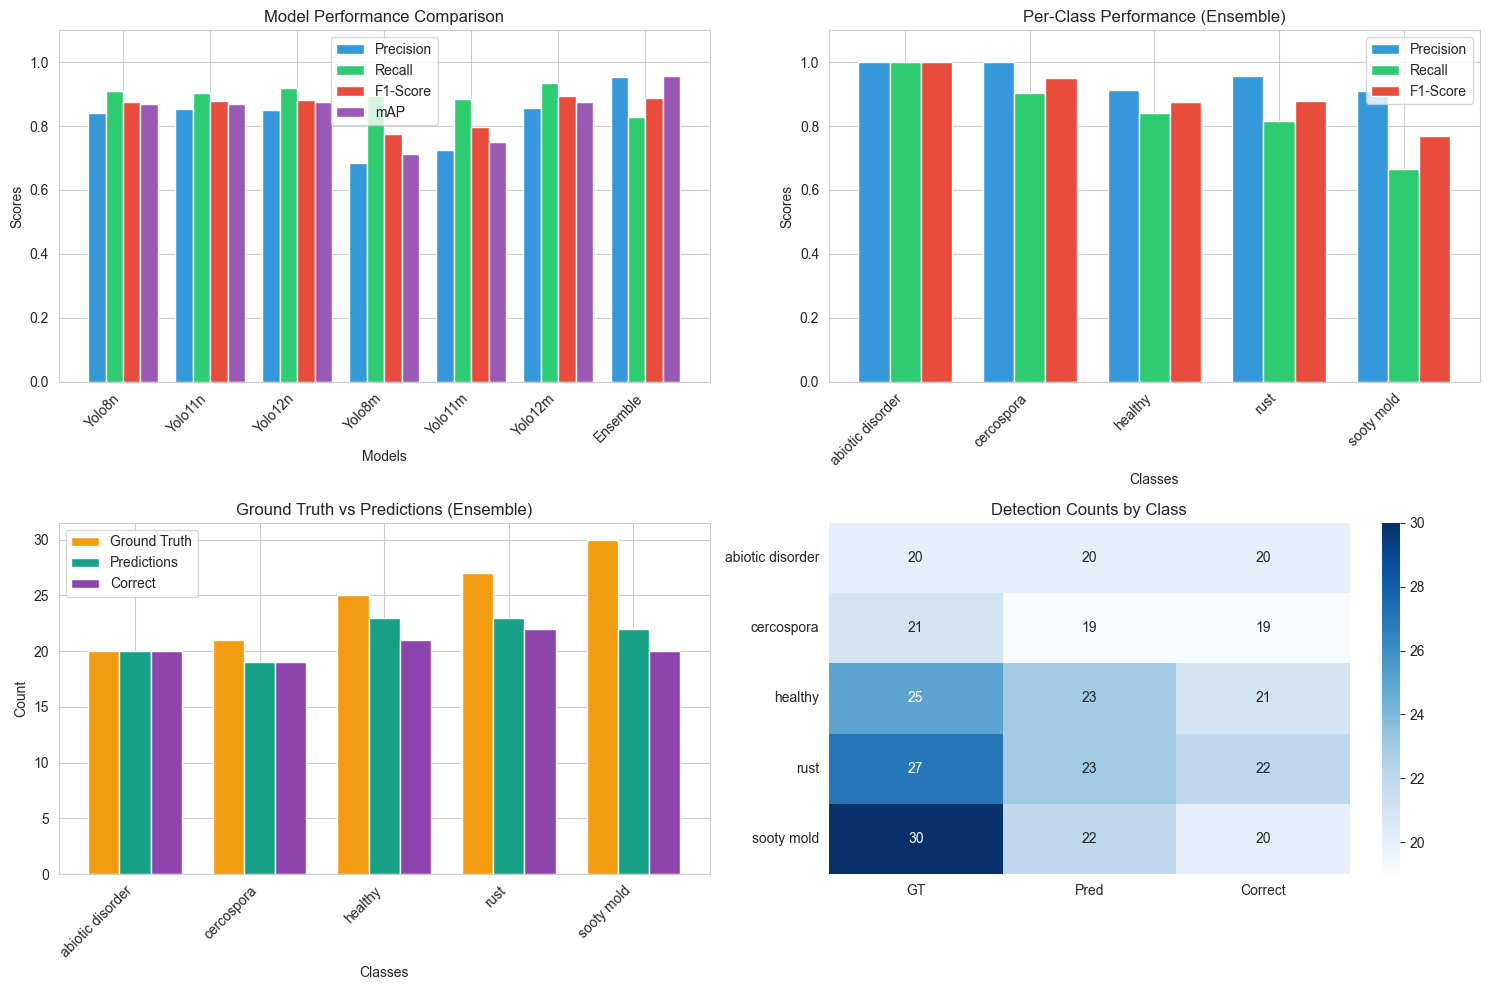

Results saved to model_evaluation_results.csv
Class metrics saved to class_evaluation_results.csv
Creating ensemble visualizations...
1/5: Creating process flow diagram...
2/5: Creating consensus filtering diagram...


C:\Users\Nicko\AppData\Local\Temp\ipykernel_26540\126011114.py:225: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Nicko\AppData\Local\Temp\ipykernel_26540\126011114.py:225: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Nicko\AppData\Local\Temp\ipykernel_26540\126011114.py:226: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig(
C:\Users\Nicko\AppData\Local\Temp\ipykernel_26540\126011114.py:226: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig(


3/5: Creating model agreement visualization...

image 1/1 E:\Thesis - Coffee\Local Training\Data\Coffee-Leaf-Diseases---OD-10\test\images\123__roi_backremoved_jpg.rf.028bc36aa34e9fa403fdf20b362aa617.jpg: 640x640 1 cercospora, 16.6ms
Speed: 2.9ms preprocess, 16.6ms inference, 3.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 E:\Thesis - Coffee\Local Training\Data\Coffee-Leaf-Diseases---OD-10\test\images\123__roi_backremoved_jpg.rf.028bc36aa34e9fa403fdf20b362aa617.jpg: 640x640 1 cercospora, 15.8ms
Speed: 2.1ms preprocess, 15.8ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 E:\Thesis - Coffee\Local Training\Data\Coffee-Leaf-Diseases---OD-10\test\images\123__roi_backremoved_jpg.rf.028bc36aa34e9fa403fdf20b362aa617.jpg: 640x640 1 cercospora, 27.7ms
Speed: 2.2ms preprocess, 27.7ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 E:\Thesis - Coffee\Local Training\Data\Coffee-Leaf-Diseases---OD-10\test\images\123__roi_back

In [ ]:
if __name__ == "__main__":
    main()


Loading models...
Successfully loaded model: paths/Yolo8n.pt
Successfully loaded model: paths/Yolo11n.pt
Successfully loaded model: paths/Yolo12n.pt
Successfully loaded model: paths/Yolo8m.pt
Successfully loaded model: paths/Yolo11m.pt
Successfully loaded model: paths/Yolo12m.pt

Testing on single image: D:\Downloads\cerc.png
Running model 1/6: Yolo8n

0: 640x512 4 abiotic disorders, 1 healthy, 4 rusts, 2 sooty molds, 11.2ms
Speed: 2.3ms preprocess, 11.2ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 512)
Running model 2/6: Yolo11n

0: 640x512 18 cercosporas, 13.5ms
Speed: 1.8ms preprocess, 13.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 512)
Running model 3/6: Yolo12n

0: 640x512 1 abiotic disorder, 11 cercosporas, 4 rusts, 19.2ms
Speed: 2.7ms preprocess, 19.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 512)
Running model 4/6: Yolo8m

0: 640x512 7 abiotic disorders, 12 cercosporas, 17 rusts, 34.4ms
Speed: 1.8ms preprocess, 34.4ms inf

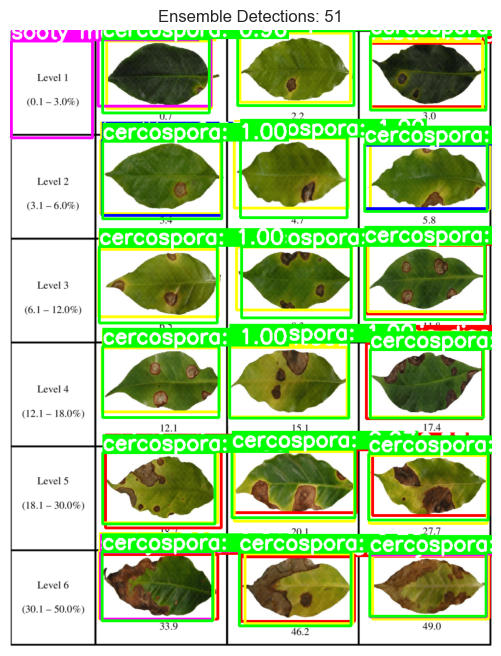

Visualization saved to output_cerc.png
Single image test complete


In [78]:
test_image_path = "D:\Downloads\cerc.png"
main(test_image_path)
